# Modelling

**Date:** 12/03/2026

This notebook is used for modelling and processing data that was analysed in the EDA notebook. We will preprocess the data, select features, and test models using hyperparameter tuning.

**Model Progression:**

1. Dummy Classifier – baseline
2. Decision Tree – simple, interpretable
3. Random Forest – more powerful ensemble
4. XGBoost – more complex, often delivers the best performance


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [2]:
df_clean = pd.read_csv('../data/processed/df_clean.csv') # import our cleaned data

In [3]:
X = df_clean.drop(columns=['DEFAULT']) # remove target from out features
y = df_clean['DEFAULT'] 


print('X shape: ', X.shape)
print('y shape: ', y.shape)

X shape:  (29601, 23)
y shape:  (29601,)


We split our data into training and testing samples with a `test_size` of 0.2. This leaves around 5,921 instances for testing, which is enough to meaningfully evaluate recall and other metrics. We use `stratify=y` here to ensure that the training sample is representative of the overall class balance in the dataset.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

In [5]:
y_train.describe()

count    23680.000000
mean         0.223142
std          0.416362
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: DEFAULT, dtype: float64

In [6]:
num_cols = ['LIMIT_BAL', 'AGE','BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 
            'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6' ]

cat_cols = ['SEX', 'MARRIAGE']

ordinal_cols = ['EDUCATION',  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']



In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

Creating the sub-pipelines. The numerical pipeline is first transformed using the PowerTransformer (with `method='yeo-johnson'`), which handles negative values unlike a log transformation. The data is then scaled. The categorical features are one-hot encoded, while the ordinal categories are kept as they are.

In [8]:
# numerical pipeline: PowerTransformer -> StandardScaler
num_pipe = Pipeline(steps=[
    ('power_trans', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler()),
])

# categorical pipeline: OneHotEncoder
cat_pipe = Pipeline(steps=[
    ('one_hot', OneHotEncoder())
])

In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('num_pipe', num_pipe, num_cols),
    ('cat_pipe', cat_pipe, cat_cols),
    ('ordinal', 'passthrough', ordinal_cols) # ordinal columns are just passed through 
])

### Dummy Classifier

In [10]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='most_frequent')

dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dummy', dummy_clf)
])

In [11]:
dummy_fit = dummy_pipeline.fit(X_train, y_train)

dummy_pred = dummy_fit.predict(X_test)

In [12]:
from sklearn.metrics import classification_report

dummy_report = classification_report(y_test, dummy_pred)

/Users/shakurahmad/PythonProjects/credit-risk-project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shakurahmad/PythonProjects/credit-risk-project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shakurahmad/PythonProjects/credit-risk-project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

In [13]:
print(dummy_report)

              precision    recall  f1-score   support

           0       0.78      1.00      0.87      4600
           1       0.00      0.00      0.00      1321

    accuracy                           0.78      5921
   macro avg       0.39      0.50      0.44      5921
weighted avg       0.60      0.78      0.68      5921



We have used a dummy classifier to generate a baseline result for precision and recall. Precision, recall, and F1 are all 0 for defaulters. The model never predicts a default.

### Decision Tree Classifier

We will start by looking at a single Decision Tree. It is simple to interpret and debug.


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=13)

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('decision_tree', dt_clf)
])

In [15]:
dt_fit = dt_pipeline.fit(X_train, y_train)
dt_predict = dt_fit.predict(X_test)

dt_report = classification_report(y_test, dt_predict)

print(dt_report)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4600
           1       0.39      0.42      0.41      1321

    accuracy                           0.73      5921
   macro avg       0.61      0.62      0.61      5921
weighted avg       0.73      0.73      0.73      5921



Recall for defaulters increased from 0 to 0.42. This means the model is now identifying 42% of actual defaulters. Accuracy has decreased slightly, as the decision tree is now predicting some class 1 cases, which means it is misclassifying some class 0 cases. This reduces accuracy, but the trade-off in favour of improved recall is far more important.


### Random Forest Classifier

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=13)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest', rf_clf)
])

In [17]:
rf_fit = rf_pipeline.fit(X_train, y_train)
rf_predict = rf_fit.predict(X_test)

rf_report = classification_report(y_test, rf_predict)

print(rf_report)

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4600
           1       0.65      0.40      0.50      1321

    accuracy                           0.82      5921
   macro avg       0.75      0.67      0.69      5921
weighted avg       0.80      0.82      0.80      5921



We see that precision for defaulters increased from 0.39 to 0.65, while recall dropped from 0.42 to 0.40. This shows that the model is becoming more cautious: when it predicts that someone will default, it is more often correct, but it misses more actual defaulters. Although recall is more important for this problem, the drop is only slight, and the F1 score improved from 0.41 to 0.50.


### XGBoost 

In [18]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(random_state=13)

xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', xgb_clf)
])

In [19]:
xgb_fit = xgb_pipe.fit(X_train, y_train)
xgb_pred = xgb_fit.predict(X_test)

xgb_report = classification_report(y_test, xgb_pred)
print(xgb_report)


              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4600
           1       0.64      0.39      0.48      1321

    accuracy                           0.81      5921
   macro avg       0.74      0.66      0.69      5921
weighted avg       0.80      0.81      0.80      5921



XGBoost performs slightly worse than Random Forest on most metrics with the default tuning. The table below shows a comparison of the models’ precision, recall, and F1 scores.

|Model | Precision (1) | Recall (1) | F1 (1) |
|------|---------------|------------|--------|
|Dummy | 0.00 | 0.00 | 0.00 |
|Decision Tree | 0.39 | 0.42 | 0.41 | 
|Random Forest | 0.65 | 0.40| 0.50|
|XGBoost | 0.64 | 0.39| 0.48|

We generate a confusion matrix for our best model so far (the Random Forest model). This will show how many defaulters we are missing (false negatives) versus how many non-defaulters we have incorrectly flagged. Here, false negatives are the most costly, as reducing them helps save the business money.


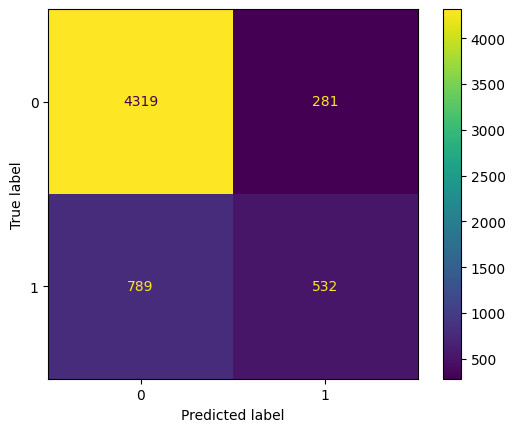

In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_predict)

ConfusionMatrixDisplay(rf_cm).plot()

789 out of 1,321 actual defaulters are being missed. This is a 60% miss rate. The model is biased toward predicting class 0, so class_weight would be an important hyperparameter to explore. 

In [21]:
rf_clf_balanced = RandomForestClassifier(class_weight='balanced' ,random_state=13) 

rf_balanced_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest_bal', rf_clf_balanced)
])

# Scikit adjusts the weights of each class inversely proportional to their frequency

rf_balanced_fit = rf_balanced_pipeline.fit(X_train, y_train)

rf_balanced_pred = rf_balanced_fit.predict(X_test)

rf_balanced_report = classification_report(y_test, rf_balanced_pred)

print(rf_balanced_report)

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4600
           1       0.65      0.36      0.47      1321

    accuracy                           0.81      5921
   macro avg       0.74      0.65      0.68      5921
weighted avg       0.79      0.81      0.79      5921



The recall score for class 1 has actually decreased. Therefore, class_weight=balanced is not enough on its own. Instead, we will use a GridSearchCV to explore combinations of hyperparameters. 

- n_estimators - number of trees. More trees = more stable but slower
- max-depth - how deep. Too deep = overfitting, too shallow - underfitting
- class_weight - deals with class imbalance. 

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'random_forest__n_estimators' : [100,200, 300], # typically 100-500
    'random_forest__max_depth': [None, 5, 10, 20], # None often overfits the data
    'random_forest__class_weight':[None, 'balanced'] 
}

We want our focus on recall, so we will use it as our scoring metric. 

In [23]:
rf_grid_search = GridSearchCV(rf_pipeline, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1) # n_jobs to use all CPU cores

rf_grid_search_fit = rf_grid_search.fit(X_train, y_train)

In [24]:
print(rf_grid_search_fit.best_params_, rf_grid_search_fit.best_score_)

{'random_forest__class_weight': 'balanced', 'random_forest__max_depth': 5, 'random_forest__n_estimators': 300} 0.586675589862676


We will try new values for n_estimators greater than 300, keeping the found parameters fixed.

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid_n = {
    'random_forest__n_estimators' : [300, 400, 500], # Try high values then first time
    'random_forest__max_depth': [5], 
    'random_forest__class_weight':['balanced'] # keep these two fixed
}

rf_grid_search_n = GridSearchCV(rf_pipeline, param_grid=param_grid_n, cv=5, scoring='recall', n_jobs=-1) # n_jobs to use all CPU cores

rf_grid_search_fit_n = rf_grid_search_n.fit(X_train, y_train)
print(rf_grid_search_fit_n.best_params_, rf_grid_search_fit_n.best_score_)


{'random_forest__class_weight': 'balanced', 'random_forest__max_depth': 5, 'random_forest__n_estimators': 500} 0.5889461669676901


The score has gone up and n_estimators is better at 500, however the return is diminishing so there is no real need to push this further. 

In [26]:
rf_grid_pred = rf_grid_search_fit_n.best_estimator_.predict(X_test)

rf_grid_report = classification_report(y_test, rf_grid_pred)
print(rf_grid_report)

              precision    recall  f1-score   support

           0       0.88      0.83      0.86      4600
           1       0.51      0.61      0.56      1321

    accuracy                           0.78      5921
   macro avg       0.70      0.72      0.71      5921
weighted avg       0.80      0.78      0.79      5921



We note that there is significant impovement. Comparing this to the untined Random Forest:

- Recall for class 1: 0.40 -> 0.61 (catching more defaulters)
- Precision for class 1: 0.65 -> 0.51 (trade-off expected)
- F1 for class 1: 0.50 -> 0.56 (overall improvement)

We explore feature selection now that we have a baseline to compare it with. 

In [27]:
rf_feat_importance = rf_grid_search_fit_n.best_estimator_.named_steps['random_forest'].feature_importances_
rf_feat_importance

array([3.40944394e-02, 2.36125534e-03, 1.51515827e-02, 1.00187254e-02,
       6.91029803e-03, 7.33591313e-03, 6.42378295e-03, 4.17098468e-03,
       3.41755296e-02, 2.73203536e-02, 2.63408341e-02, 1.94405771e-02,
       1.10780369e-02, 1.31489263e-02, 3.90292790e-04, 2.59072567e-04,
       3.54933350e-04, 4.62480834e-04, 8.31725138e-05, 1.25529394e-03,
       3.29228671e-01, 1.62523121e-01, 1.13619728e-01, 7.04468485e-02,
       6.37086435e-02, 3.96965040e-02])

In [28]:
rf_feat_names = rf_grid_search_fit_n.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
rf_feat_names

array(['num_pipe__LIMIT_BAL', 'num_pipe__AGE', 'num_pipe__BILL_AMT1',
       'num_pipe__BILL_AMT2', 'num_pipe__BILL_AMT3',
       'num_pipe__BILL_AMT4', 'num_pipe__BILL_AMT5',
       'num_pipe__BILL_AMT6', 'num_pipe__PAY_AMT1', 'num_pipe__PAY_AMT2',
       'num_pipe__PAY_AMT3', 'num_pipe__PAY_AMT4', 'num_pipe__PAY_AMT5',
       'num_pipe__PAY_AMT6', 'cat_pipe__SEX_1', 'cat_pipe__SEX_2',
       'cat_pipe__MARRIAGE_1', 'cat_pipe__MARRIAGE_2',
       'cat_pipe__MARRIAGE_3', 'ordinal__EDUCATION', 'ordinal__PAY_0',
       'ordinal__PAY_2', 'ordinal__PAY_3', 'ordinal__PAY_4',
       'ordinal__PAY_5', 'ordinal__PAY_6'], dtype=object)

In [29]:
rf_df_importance = pd.DataFrame({'Feature_names' : [name.split('__')[1] for name in rf_feat_names], "Feature_importance" : rf_feat_importance})

rf_df_importance_sorted = rf_df_importance.sort_values(by='Feature_importance', ascending=True)


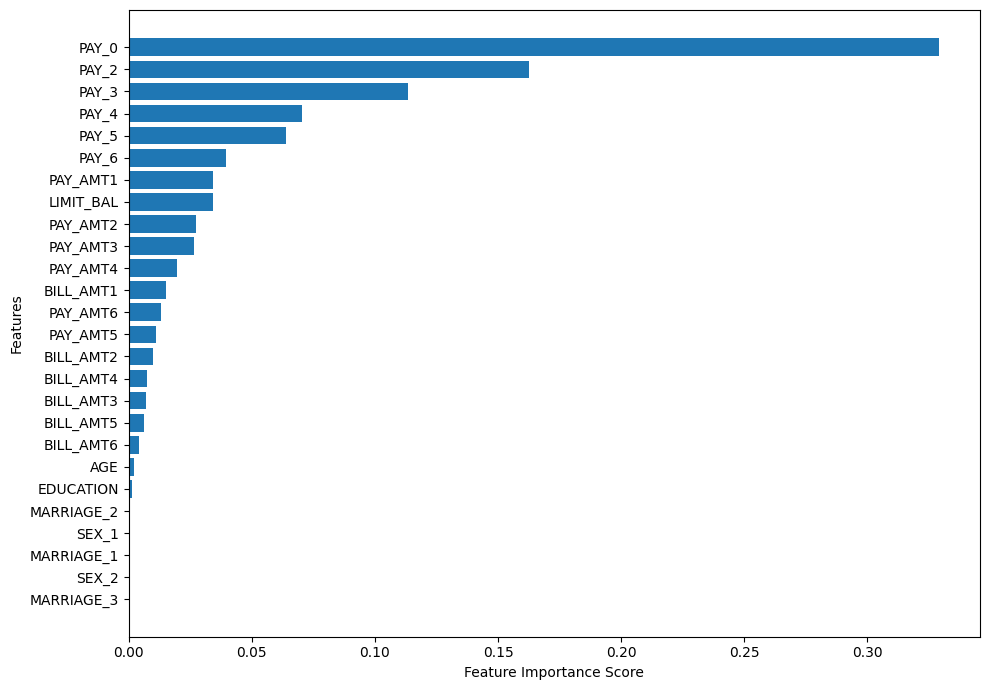

In [30]:
plt.figure(figsize=(10, 7))
plt.barh(rf_df_importance_sorted['Feature_names'], rf_df_importance_sorted['Feature_importance'])
plt.ylabel("Features")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

From this graph, we note that marriage, sex, and education do not contribute greatly, which matches our EDA. However, sex and marriage are demographic features, so by removing them, we lose the ability to analyse whether the model treats different groups differently. This could raise ethical concerns; however, for this project, I will focus only on whether they improve predictive performance. In a real production setting, we would likely retain demographic features for fairness auditing.

We will now explore our model’s capabilities using a reduced feature set and evaluate how it performs compared with the full feature set. Education, age, sex, and marriage will be removed, as they scored the lowest in terms of feature importance.


In [31]:
# Reduced feature list

red_num_cols = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 
            'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6' ]


red_ordinal_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

red_preprocessor = ColumnTransformer(transformers=[
    ('red_num_cols', num_pipe, red_num_cols),
    ('red_ordinal', 'passthrough', red_ordinal_cols) # ordinal columns are just passed through 
])

In [32]:
# new model instance using tuned hyperparams
rf_clf_red = RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=500, random_state=13)

# reduced feature pipe
red_rf_pipe = Pipeline(steps=[
    ('red_col_trans', red_preprocessor),
    ('rf_clf_red', rf_clf_red)
])

In [33]:
red_rf_fit = red_rf_pipe.fit(X_train, y_train)
red_rf_pred = red_rf_fit.predict(X_test)

red_rf_report = classification_report(y_test, red_rf_pred)
print(red_rf_report)

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4600
           1       0.51      0.61      0.55      1321

    accuracy                           0.78      5921
   macro avg       0.69      0.72      0.70      5921
weighted avg       0.80      0.78      0.79      5921



The results are identical with the reduced feature set, which confirms that the feature importance scores were correct. The model is entirely driven by the repayment status and financial amount features. Moving forward, we can work with the reduced set, as fewer features mean a simpler, faster model that is easier to explain.

Moving to the deployment phase of the project we will be taking forward the Random Forest Classifier model with its tuned parameters. This model has conssitently performed the best in terms of key matrics (precision, recall and f1) for class 1. In particular it scores well for recall, which is a proprity on this project as we do not want defaulters to slip through. Overall for class 1 it scores 0.61 for recall and 0.51 for precision with and F1 score of 0.55. 

The next step will include buidling a prediction APT and a simple frontend so it can be deployed. 

## Save Model 

joblib.dump() serialises our Python object (trained pipeline) into a bibnary file on disk. LAter, joblib.load() reads that file and recreated the exact sam pipeiline. 

In [34]:
import joblib  # save the model with joblib
joblib.dump(red_rf_pipe, '../models/rf_model.pkl')

['../models/rf_model.pkl']

In [35]:
# verify the model works 

loaded_model = joblib.load('../models/rf_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
print(test_pred)

[0 1 0 0 0]
